# Peak-to-Gene Linkage


`epione.tl.peak_to_gene` ports ArchR's `addPeak2GeneLinks`: kNN metacells over a joint embedding → mean-aggregate peak and gene matrices → per-pair Pearson correlation with Student-t + BH FDR.

`epione.pl.plot_peak2gene` renders an ArchR-style browser track — per-group pseudobulk coverage, peaks, half-ellipse link arcs, and a UCSC-style gene model — **without requiring BigWig files**.


## Data Preparation

snapatac2 bundles pre-processed h5ad files of the 10x PBMC 10k multiome dataset. ATAC and RNA share barcodes — keep the intersection.


In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import os, pathlib
os.environ['XDG_CACHE_HOME'] = '/scratch/users/steorra/cache'

import numpy as np
import pandas as pd
import anndata as ad
import scanpy as sc
from IPython.display import display
import epione as epi
import matplotlib.pyplot as plt

epi.pl.plot_set()

WORK = pathlib.Path('/scratch/users/steorra/data/pbmc10k_p2g')
WORK.mkdir(parents=True, exist_ok=True)


└─ 🔬 Starting plot initialization...
  ├─ Apply Scanpy/matplotlib settings
  ├─ Custom font setup
  ├─ Suppress warnings
  ├─ 
___________      .__                      
\_   _____/_____ |__| ____   ____   ____  
 |    __)_\____ \|  |/  _ \ /    \_/ __ \ 
 |        \  |_> >  (  <_> )   |  \  ___/ 
/_______  /   __/|__|\____/|___|  /\___  >
        \/|__|                  \/     \/ 

  ├─ 🔖 Version: 0.0.1rc1   📚 Tutorials: https://epione.readthedocs.io/
└─ ✅ plot_set complete.



In [2]:
# Load the PBMC 10k multiome ATAC + RNA h5ad files. Both are in
# the epione dataset registry; pooch downloads + caches them on
# first use.
DS = epi.utils.register_datasets()
atac = ad.read_h5ad(DS.fetch('10x-Multiome-Pbmc10k-ATAC.h5ad'))
rna  = ad.read_h5ad(DS.fetch('10x-Multiome-Pbmc10k-RNA.h5ad'))
print(atac)
print(rna)


AnnData object with n_obs × n_vars = 9631 × 107194
    obs: 'domain', 'cell_type'
    var: 'feature_types'
    uns: 'spectral_eigenvalue'
    obsm: 'X_spectral', 'X_umap'
AnnData object with n_obs × n_vars = 9631 × 29095
    obs: 'domain', 'cell_type'
    var: 'gene_ids', 'feature_types'


In [3]:
common = atac.obs_names.intersection(rna.obs_names)
atac = atac[common].copy()
rna  = rna[common].copy()
atac.obs['n_fragment'] = np.asarray(atac.X.sum(axis=1)).ravel()
atac.shape, rna.shape


((9631, 107194), (9631, 29095))

## Iterative LSI on the ATAC matrix

`peak_to_gene` needs a dense low-dimensional embedding to build kNN metacells from. Iterative LSI is the canonical choice for scATAC.


In [4]:
%%time
epi.tl.iterative_lsi(
    atac,
    n_components=30,
    iterations=2,
    var_features=25_000,
    resolution=0.5,
    n_neighbors=30,
    sample_cells_pre=10_000,
    depth_col='n_fragment',
    seed=1,
)
atac.obsm['X_iterative_lsi'].shape


  └─ [iterative_lsi] Initial feature set: 106,658 / 107,194


  └─ [iterative_lsi] Iter 1/2 | fit on 9,631 cells x 106,658 features


computing neighbors


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:36)


running Leiden clustering


    finished: found 15 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:00)


  └─ [iterative_lsi]   -> 15 clusters; selected 25,000 variable features for next round


  └─ [iterative_lsi] Iter 2/2 | fit on 9,631 cells x 25,000 features


  └─ [iterative_lsi] Done. Stored embedding (9,631 x 29) in adata.obsm['X_iterative_lsi']
CPU times: user 2min 26s, sys: 5.14 s, total: 2min 31s
Wall time: 1min 33s


(9631, 29)

## Gene annotation

Per-gene coordinates define the ±`max_distance` window around each TSS. snapatac2 ships a cached GENCODE hg38 GFF3.


In [5]:
import pyranges as pr
gtf_path = epi.utils.genome.hg38.annotation
g = pr.read_gff3(str(gtf_path)).df

gene_ann = pd.DataFrame({
    'gene_name': g.loc[g.Feature == 'gene', 'gene_name'].astype(str).values,
    'chrom':     g.loc[g.Feature == 'gene', 'Chromosome'].astype(str).values,
    'start':     g.loc[g.Feature == 'gene', 'Start'].astype(int).values,
    'end':       g.loc[g.Feature == 'gene', 'End'].astype(int).values,
    'strand':    g.loc[g.Feature == 'gene', 'Strand'].astype(str).values,
}).drop_duplicates('gene_name').reset_index(drop=True)

exon_ann = pd.DataFrame({
    'gene_name': g.loc[g.Feature == 'exon', 'gene_name'].astype(str).values,
    'chrom':     g.loc[g.Feature == 'exon', 'Chromosome'].astype(str).values,
    'start':     g.loc[g.Feature == 'exon', 'Start'].astype(int).values,
    'end':       g.loc[g.Feature == 'exon', 'End'].astype(int).values,
    'strand':    g.loc[g.Feature == 'exon', 'Strand'].astype(str).values,
})

len(gene_ann), len(exon_ann)


(60606, 839796)

## Peak-to-gene

ArchR defaults: 500 metacells × 100 neighbours, ±250 kb window, Pearson correlation, BH FDR across all tested pairs.


In [6]:
%%time
links = epi.tl.peak_to_gene(
    atac,
    rna=rna,
    gene_annotation=gene_ann,
    use_rep='X_iterative_lsi',
    n_metacells=500,
    k_neighbors=100,
    max_distance=250_000,
    seed=1,
)
links.to_parquet(WORK / 'peak_to_gene.parquet')
print(f'{len(links):,} pairs | {(links.fdr < 0.05).sum():,} FDR < 0.05')


  └─ [peak_to_gene] 107,194 peaks | 20,169 annotated genes | 9,631 cells
  └─ [peak_to_gene] Building 500 metacells × 100 neighbours from X_iterative_lsi
  └─ [peak_to_gene] Aggregating peak matrix


  └─ [peak_to_gene] Aggregating gene matrix


  └─ [peak_to_gene] Finding peak-gene pairs within ±250,000 bp


  └─ [peak_to_gene] 726,292 candidate pairs
  └─ [peak_to_gene] Computing correlations


  └─ [peak_to_gene] 726,292 pairs retained, 441,142 significant (FDR < 0.05)


726,292 pairs | 441,142 FDR < 0.05
CPU times: user 6.62 s, sys: 1.67 s, total: 8.29 s
Wall time: 7.61 s


In [7]:
links.reindex(links['correlation'].abs().sort_values(ascending=False).index) \
     .head(10)[['peak', 'gene', 'distance', 'correlation', 'fdr']]


,peak,gene,distance,correlation,fdr
652165,chr7:101367780-101367789,LINC01007,-201222,0.999998,0.0
652164,chr7:101367780-101367789,COL26A1,4910,0.999798,0.0
467543,chr20:9388473-9388582,LAMP5-AS1,-126471,0.999493,0.0
467542,chr20:9388473-9388582,LAMP5,-125830,0.998663,0.0
360128,chr19:5336190-5336587,PTPRS,-4424,0.998541,0.0
89849,chr10:89809057-89809192,LINC01374,-44470,0.998295,0.0
100520,chr11:634199-634286,SCT,7061,0.997344,0.0
679193,chr8:134625591-134625702,ZFAT-AS1,27576,0.997196,0.0
237289,chr15:75018870-75019357,SCAMP5,61895,0.996811,0.0
679199,chr8:134683132-134683772,ZFAT-AS1,85382,0.996300,0.0


### Summary plots


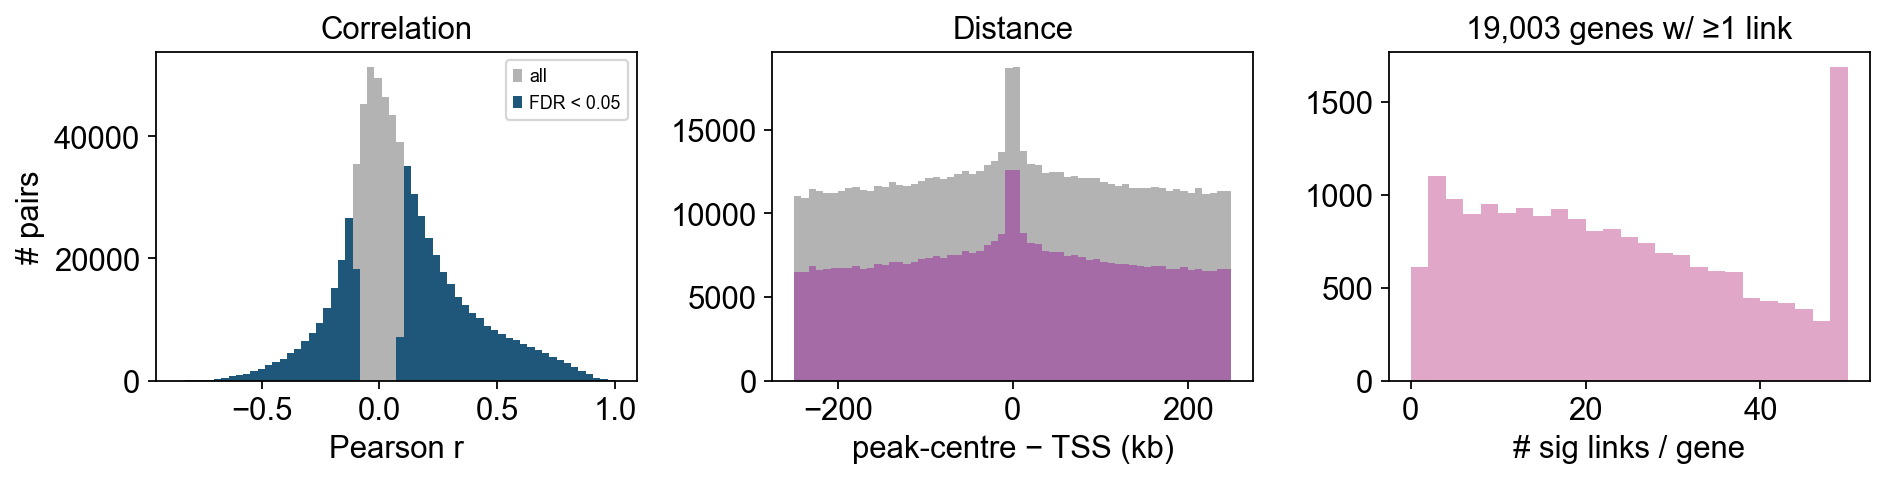

In [8]:
sig = links[links['fdr'] < 0.05]
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2))

axes[0].hist(links['correlation'],  bins=60, color='0.7', label='all')
axes[0].hist(sig['correlation'],    bins=60, color='C0',  label='FDR < 0.05')
axes[0].set_xlabel('Pearson r'); axes[0].set_ylabel('# pairs')
axes[0].legend(fontsize=8); axes[0].set_title('Correlation')

axes[1].hist(links['distance'] / 1e3, bins=60, color='0.7')
axes[1].hist(sig['distance']   / 1e3, bins=60, color='C1')
axes[1].set_xlabel('peak-centre − TSS (kb)'); axes[1].set_title('Distance')

per_gene = sig.groupby('gene').size().clip(upper=50)
axes[2].hist(per_gene, bins=np.arange(0, 52, 2), color='C2')
axes[2].set_xlabel('# sig links / gene')
axes[2].set_title(f'{per_gene.size:,} genes w/ ≥1 link')

plt.tight_layout(); display(fig); plt.close(fig)


In [9]:
for gene in ['CD3D', 'CD19', 'MS4A1', 'GNLY', 'LYZ']:
    sub = sig[sig['gene'] == gene]
    if sub.empty:
        continue
    print(f'\n{gene}: {len(sub)} significant links')
    print(sub.reindex(sub.correlation.abs().sort_values(ascending=False).index)
             .head(5)[['peak', 'distance', 'correlation']].to_string(index=False))



CD3D: 52 significant links
                     peak  distance  correlation
chr11:118337765-118347252      -197     0.882967
chr11:118304165-118308090    -36578     0.849636
chr11:118315296-118317685    -26215     0.779693
chr11:118398435-118402795     57910     0.710349
chr11:118434093-118439206     93944     0.694896

CD19: 44 significant links
                   peak  distance  correlation
chr16:28910024-28911110    -21397     0.913139
chr16:28930484-28933437        -4     0.874558
chr16:28923628-28926451     -6925     0.711179
chr16:28902003-28904135    -28895     0.576940
chr16:29007438-29010500     77005    -0.428174

MS4A1: 40 significant links
                   peak  distance  correlation
chr11:60455290-60456088      -156     0.958685
chr11:60498212-60499391     42956     0.917259
chr11:60457557-60458006      1936     0.904648
chr11:60485853-60486383     30273     0.900626
chr11:60459521-60459691      3761     0.883234

GNLY: 53 significant links
                  peak  dista

## Visualise links

`epi.pl.plot_peak2gene` draws coverage + peaks + link arcs + gene track on a genomic window around a gene. By default no BigWig files are required — per-group coverage is computed on the fly from the peak matrix with per-cell CP10k normalisation.


In [10]:
# Map fine-grained cell types to broad lineages for clearer coverage
major = {
    'CD4 Naive': 'T_CD4', 'CD4 TCM': 'T_CD4', 'CD4 TEM': 'T_CD4', 'Treg': 'T_CD4',
    'CD8 Naive': 'T_CD8', 'CD8 TEM_1': 'T_CD8', 'CD8 TEM_2': 'T_CD8',
    'MAIT': 'T_CD8', 'gdT': 'T_CD8',
    'Naive B': 'B', 'Memory B': 'B', 'Intermediate B': 'B', 'Plasma': 'B',
    'NK': 'NK', 'CD14 Mono': 'Mono', 'CD16 Mono': 'Mono',
    'cDC': 'DC', 'pDC': 'DC', 'HSPC': 'HSPC',
}
atac.obs['lineage'] = atac.obs['cell_type'].map(major).astype('category')


### Minimal: arcs + peaks + gene track


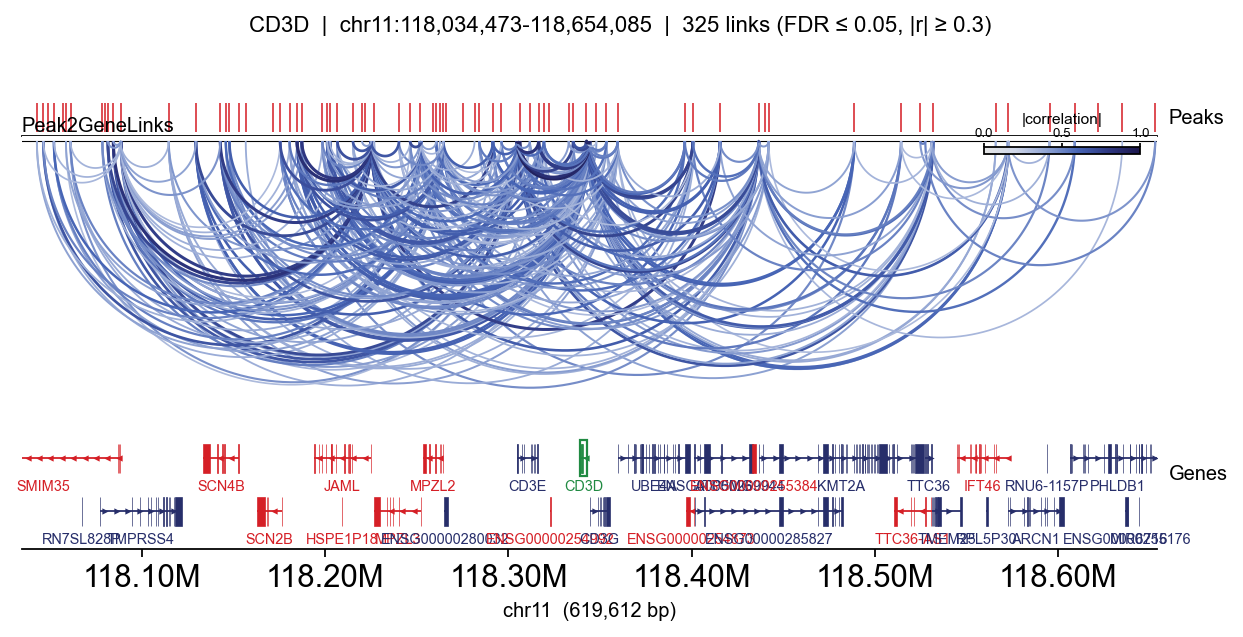

In [11]:
fig, _ = epi.pl.plot_peak2gene(
    atac, gene='CD3D',
    gene_annotation=gene_ann,
    exon_annotation=exon_ann,
    fdr_thresh=0.05, min_abs_r=0.3,
    pad_bp=80_000, figsize=(8, 4), show=False,
)
plt.tight_layout(); display(fig); plt.close(fig)


### Full track — per-lineage coverage

Passing `group_by=` adds one coverage row per category (per-cell CP10k-normalised, mean within group — so T-specific peaks appear clearly in T lineages and not elsewhere).


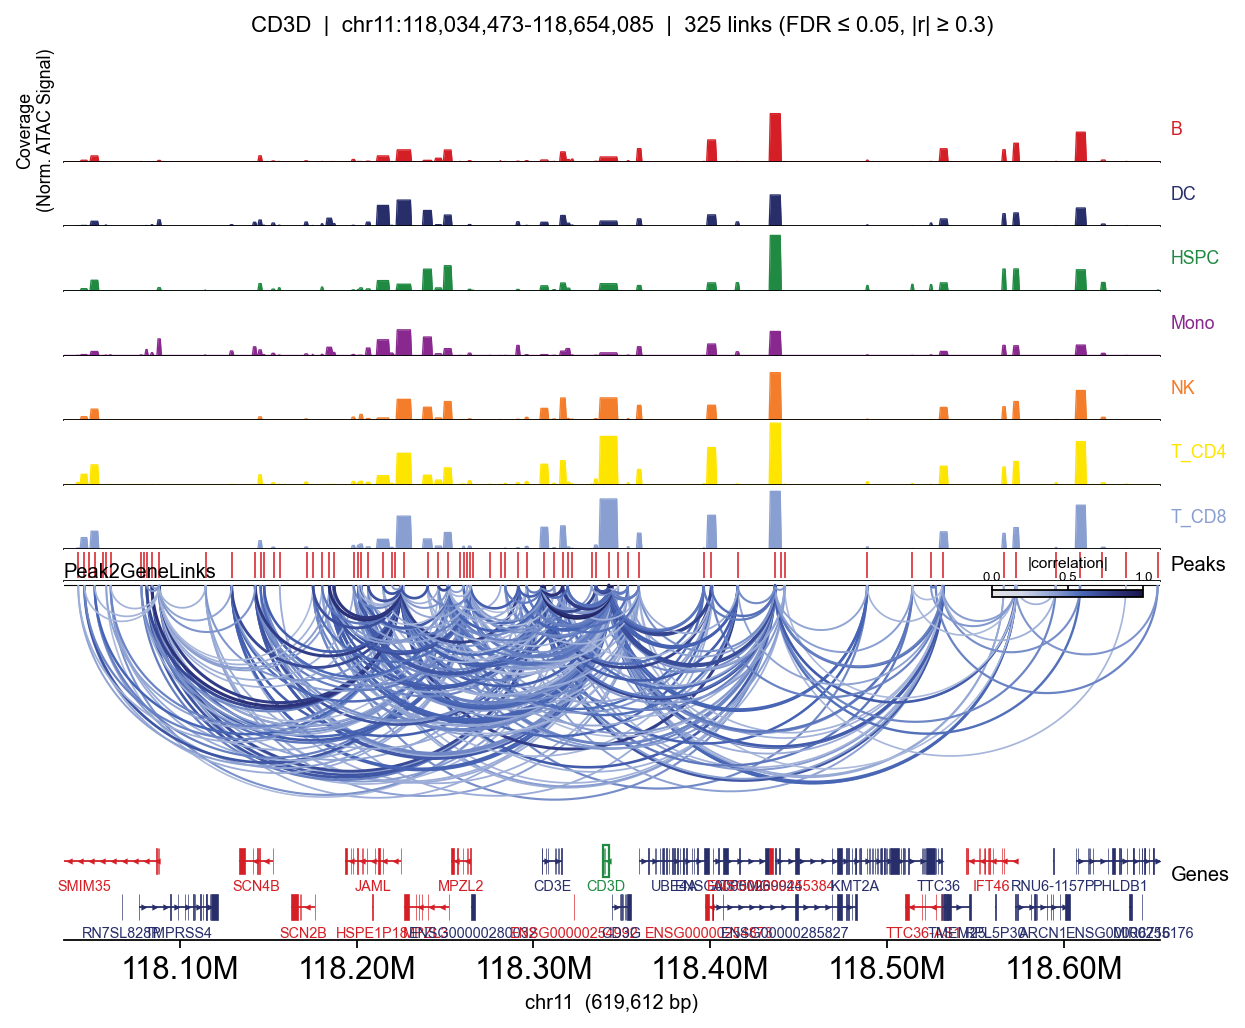

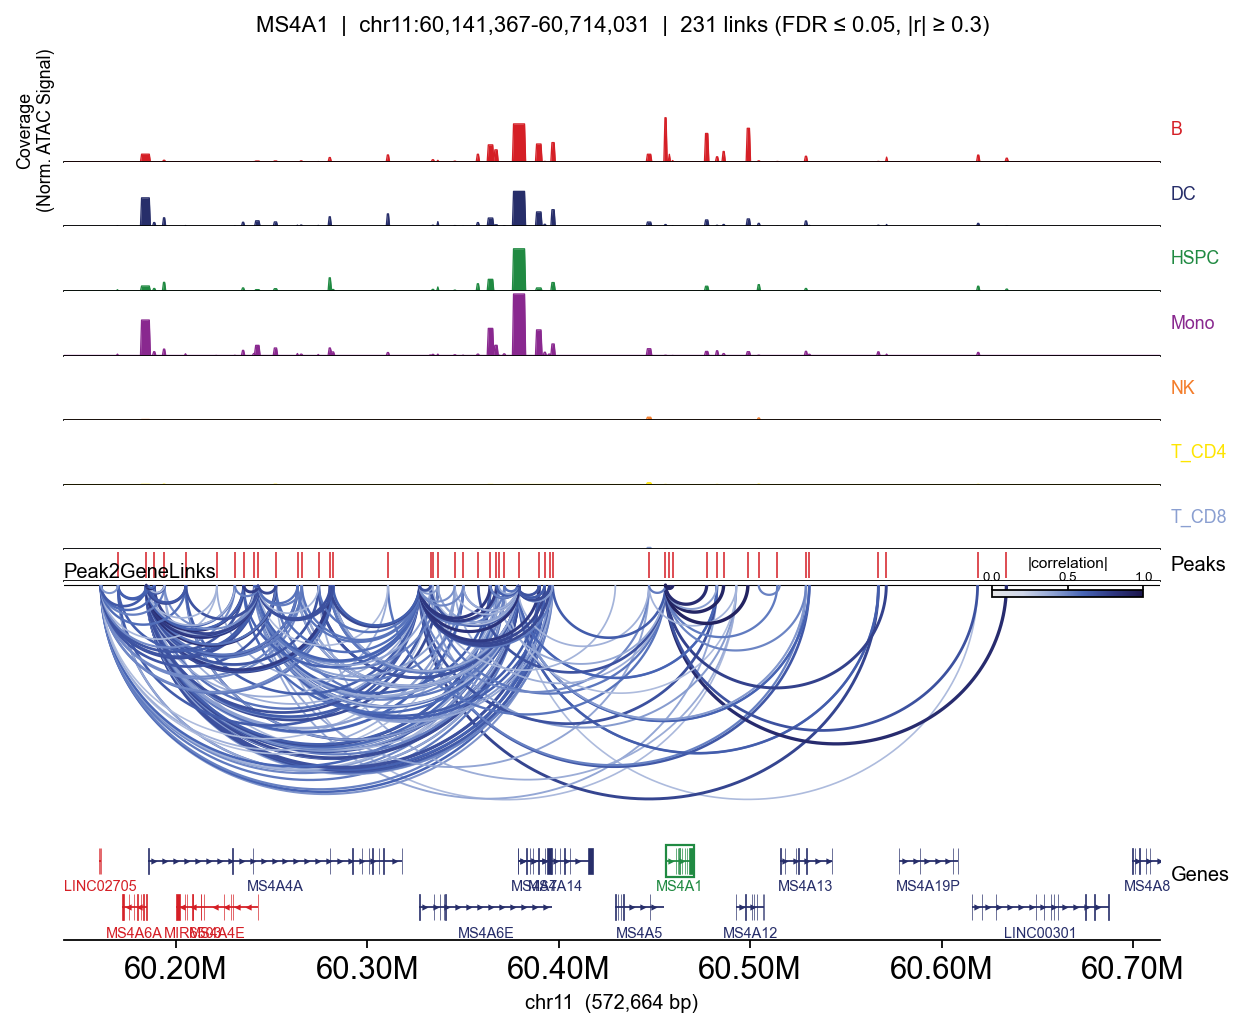

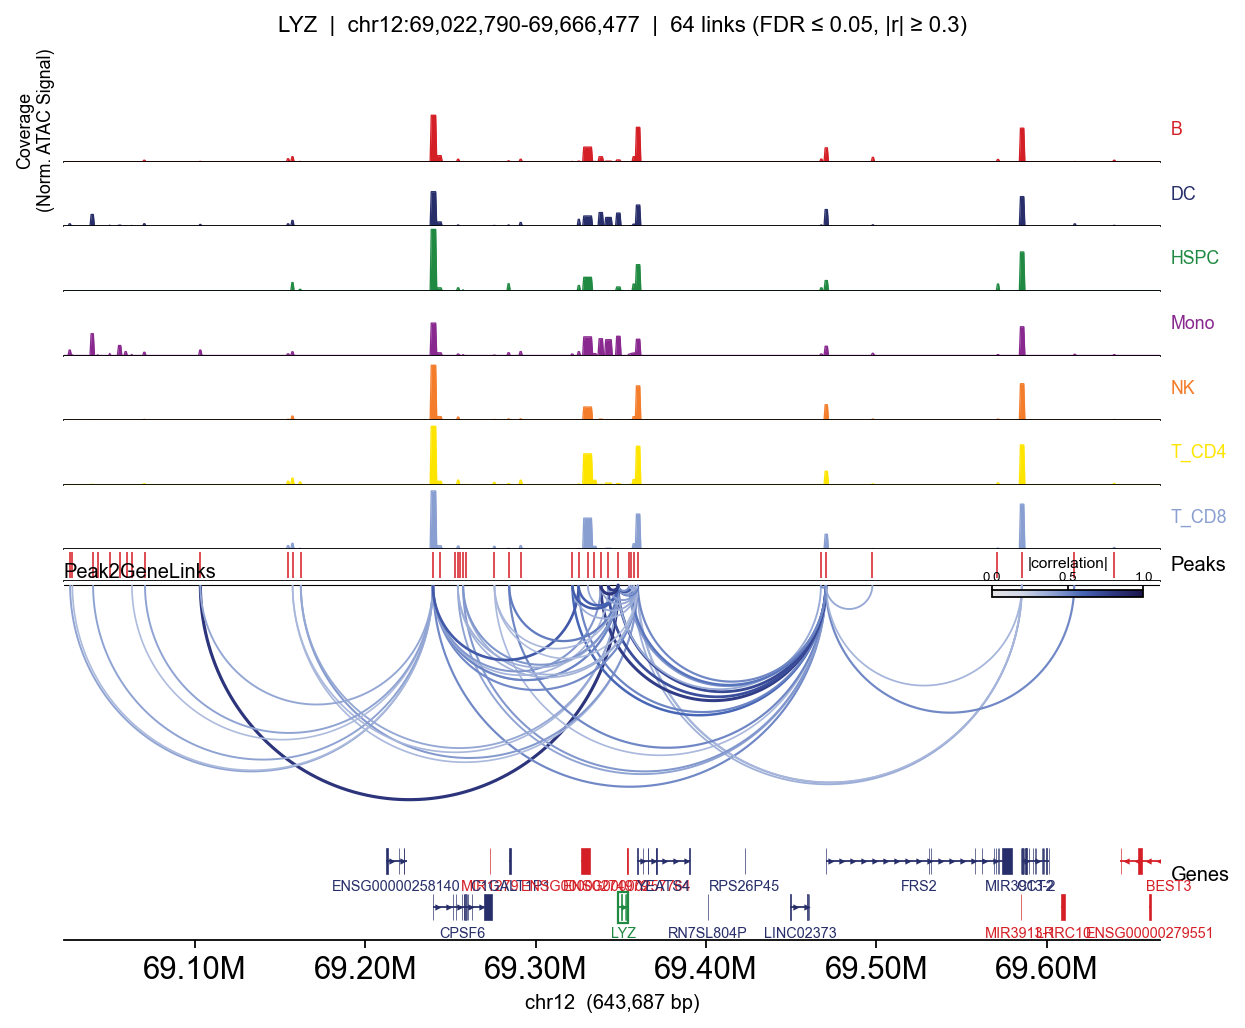

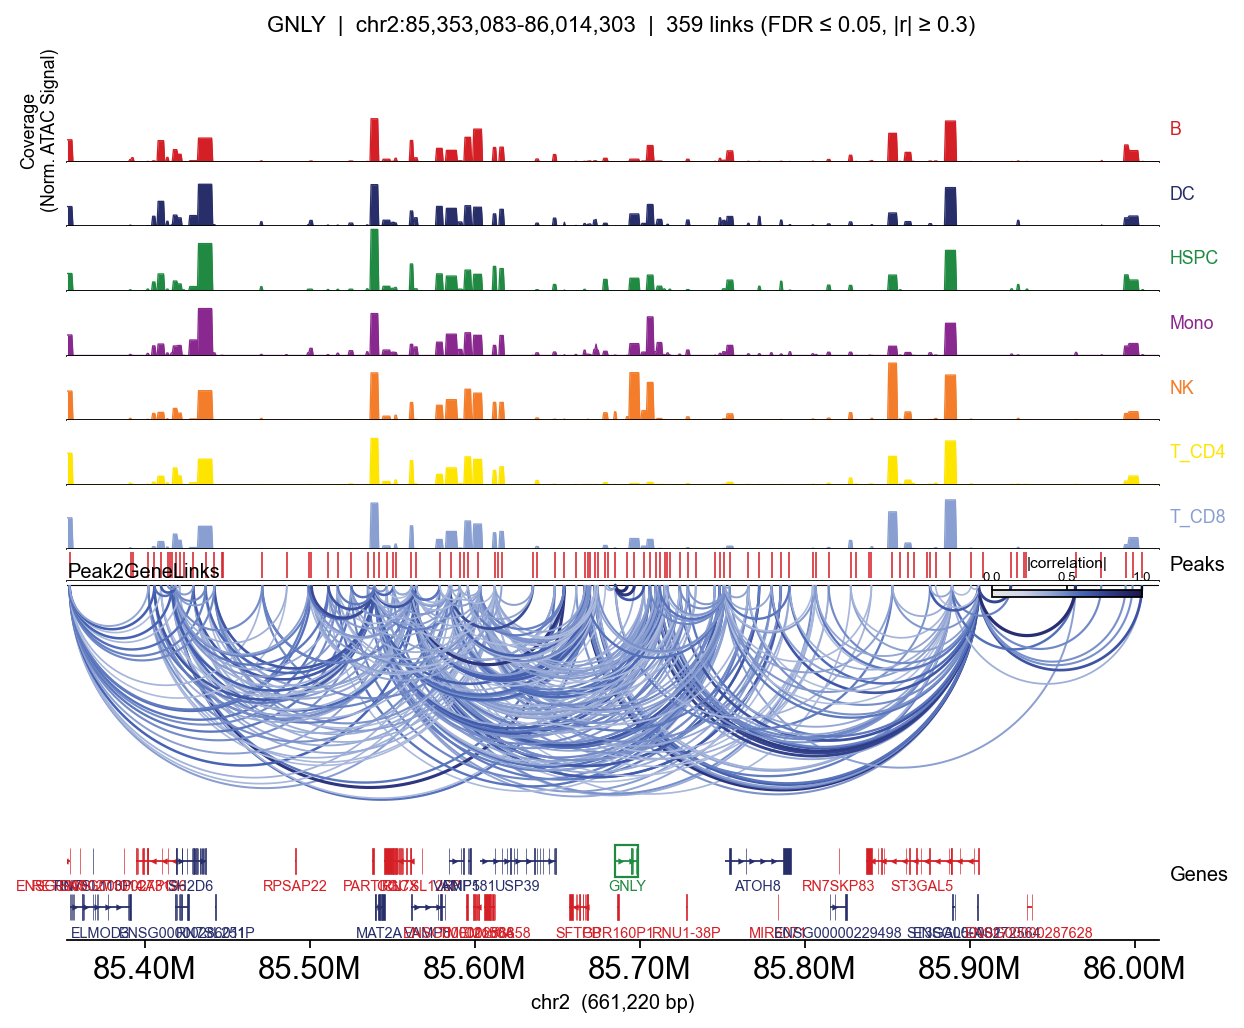

In [12]:
for gene in ['CD3D', 'MS4A1', 'LYZ', 'GNLY']:
    fig, _ = epi.pl.plot_peak2gene(
        atac, gene=gene,
        group_by='lineage',
        gene_annotation=gene_ann,
        exon_annotation=exon_ann,
        fdr_thresh=0.05, min_abs_r=0.3,
        pad_bp=80_000, figsize=(8, 4), show=False,
    )
    plt.tight_layout(); display(fig); plt.close(fig)


## Fragment-based coverage (BigWig pseudobulk)

The tracks above compute per-lineage coverage **from the peak matrix**: for each peak, the mean CP10k value within the group is painted across the peak's width. Fast (no extra I/O), but blocky — the resolution is the peak width, not bp.

For ArchR / UCSC-quality tracks we need **bp-resolution Tn5 insertion density**, which requires the fragment file. `epione.single.pseudobulk_with_fragments` does this in one call:

- Reads the fragment `.tsv.gz` (optionally cached as parquet for re-use).
- Expands each fragment to two 1-bp Tn5 cutsites with the standard ATAC shift `(+4, -5)` — or, with `bigwig_strategy='fragment'`, leaves the fragment interval intact.
- Writes one CPM-normalised BigWig per group via the Rust-backed `pybigtools` writer.
- `executor='process'` forks workers that share fragments via copy-on-write → true parallel writes (no GIL).

Pass the resulting BWs into `plot_peak2gene(bigwig_files=...)` and the coverage row swaps to bp-true signal; arcs / peaks / gene rows are unchanged.


In [13]:
frag_path = epi.utils.register_datasets().fetch('pbmc_10k_atac.tsv.gz')
print('fragment file:', frag_path)

fragment file: /scratch/users/steorra/cache/snapatac2/pbmc_10k_atac.tsv.gz


### Build per-lineage BigWigs

Barcodes in snapatac2's bundled fragment file carry no sample tag — pass `sample_id_col=None` and a single-entry `path_to_fragments`. Caching the parsed fragments as parquet pays for itself the second time you tweak parameters.


In [14]:
%%time
BW_DIR = WORK / 'pseudobulk_bw'
BW_DIR.mkdir(exist_ok=True)

chrom = pr.PyRanges(pd.DataFrame({
    'Chromosome': list(epi.utils.genome.hg38.chrom_sizes.keys()),
    'Start': 0,
    'End':   list(epi.utils.genome.hg38.chrom_sizes.values()),
}))

epi.single.pseudobulk_with_fragments(
    input_data=atac,                    # AnnData with obs['lineage']
    chromsizes=chrom,
    cluster_key='lineage',
    path_to_fragments={'pbmc10k': str(frag_path)},
    bigwig_path=str(BW_DIR),
    bed_path=None,                      # skip BED — slow, rarely needed
    bigwig_strategy='cutsite',          # Tn5 insertion density (+4/-5)
    normalize_bigwig=True,              # CPM
    cache_fragments=str(WORK / 'frag_cache'),
    executor='process',                 # fork pool for true parallel writes
    n_jobs=4,
    balance_clusters=False,
    show_progress=False,
    verbose=False,
)
bigwig_files = {p.stem: str(p) for p in BW_DIR.glob('*.bw')}
bigwig_files


CPU times: user 28.5 s, sys: 14.5 s, total: 43 s
Wall time: 1min 50s


{'T_CD8': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/T_CD8.bw',
 'HSPC': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/HSPC.bw',
 'NK': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/NK.bw',
 'Mono': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/Mono.bw',
 'T_CD4': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/T_CD4.bw',
 'DC': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/DC.bw',
 'B': '/scratch/users/steorra/data/pbmc10k_p2g/pseudobulk_bw/B.bw'}

### Side-by-side: peak-matrix approximation vs. fragment BigWig

Same gene (CD3D), same links, same gene track — only the coverage rows differ. The BigWig version shows sharp bp-resolution peaks inside each accessible region; the peak-matrix version paints each peak as a flat block.



=== peak-matrix (group_by) ===


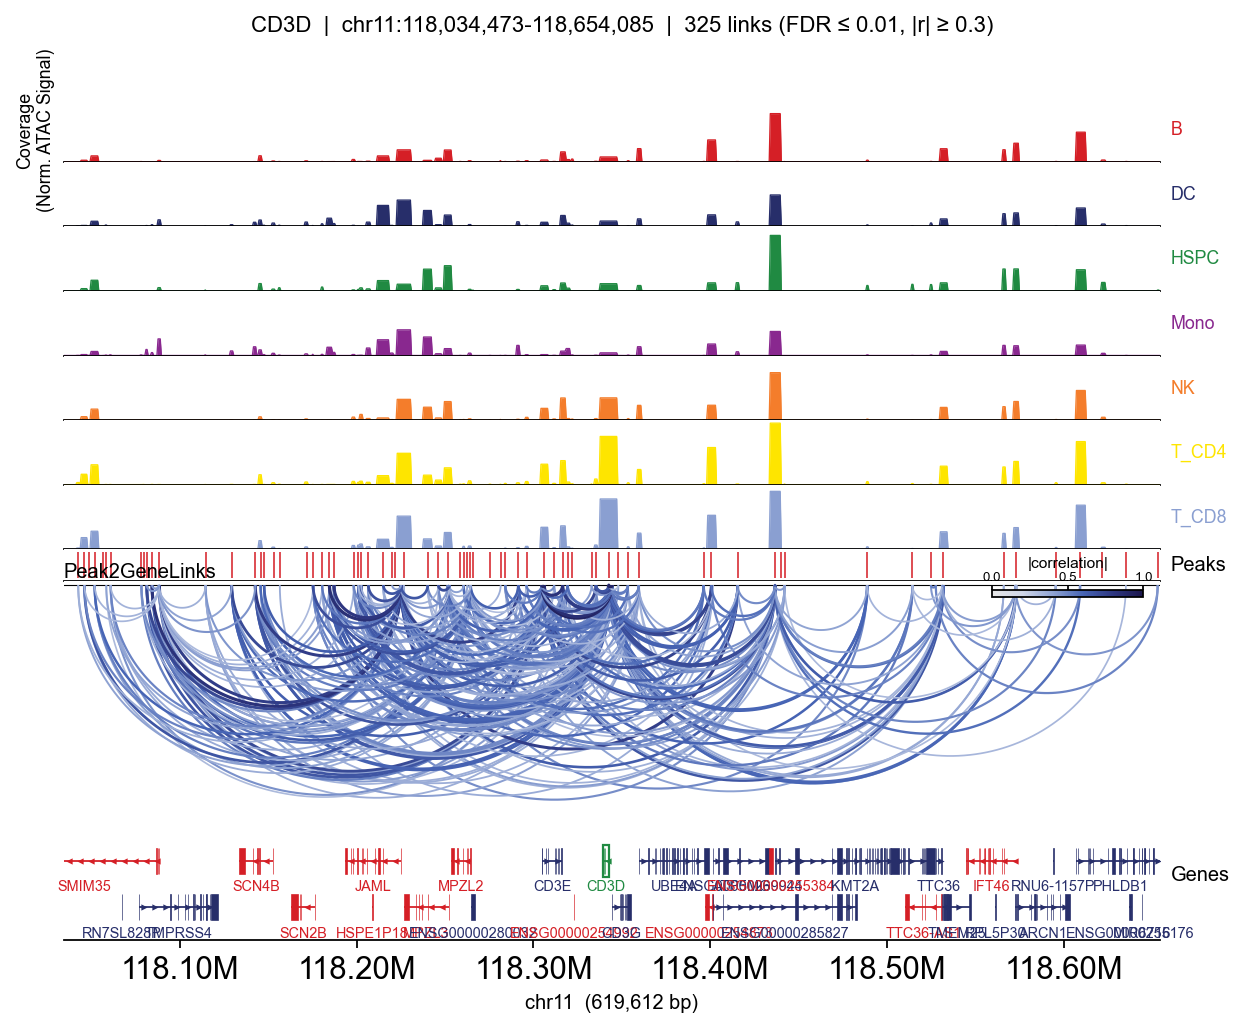


=== BigWig (fragments) ===


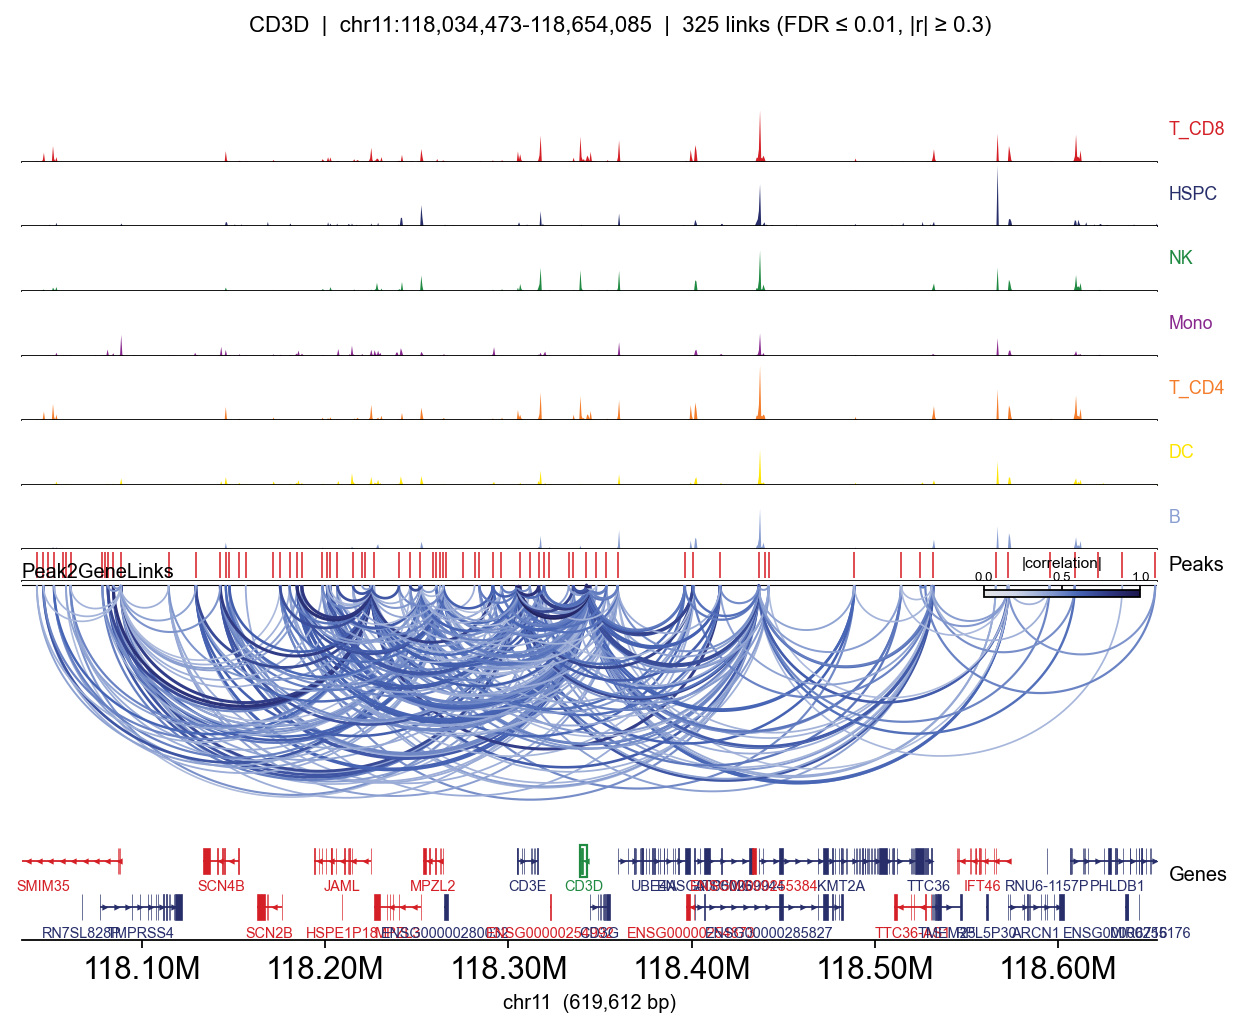

In [15]:
for mode, kwargs in [
    ('peak-matrix (group_by)', dict(group_by='lineage')),
    ('BigWig (fragments)',     dict(bigwig_files=bigwig_files)),
]:
    print(f'\n=== {mode} ===')
    fig, _ = epi.pl.plot_peak2gene(
        atac, gene='CD3D',
        gene_annotation=gene_ann,
        exon_annotation=exon_ann,
        fdr_thresh=0.01, min_abs_r=0.3,
        pad_bp=80_000, figsize=(8, 4), show=False,
        **kwargs,
    )
    plt.tight_layout(); display(fig); plt.close(fig)


## Notes

- No RNA? Pass a gene-score / gene-activity matrix instead via `gene_obsm='X_gene_score'` + `gene_names=...`. API is otherwise identical.
- Memory scales with *candidate pairs*, not cells. 250 kb × 20k genes → ≈20 hits/peak, ~`n_peaks × 20` float32.
- `n_metacells=500, k_neighbors=100` matches ArchR; bump both for higher resolution at the cost of RAM.
- Arcs use ArchR's exact `getArchDF` half-ellipse geometry (`ry = R_MAX · rx / max_rx`); gene track follows the UCSC convention (intron line + exon blocks + strand chevrons) when `exon_annotation=` is provided.
